# Secrets of Darkwood — Gaming Product Analytics

**Objective.** Evaluate real-money monetization and in-game purchasing behavior, and determine
which product changes can be validated experimentally on this audience.

**Data.** 22,214 registered players, 1,307,678 purchase transactions (PostgreSQL, schema `fantasy`).

**A note on units.** The game runs on a premium currency, *paradise petals*, earned through
quests or bought for real money. The `amount` field records spend **in petals, not in real money**.
The only revenue-bearing field in the schema is the binary `payer` flag. Buyers (players who
spend petals) and payers (players who buy petals for money) are distinct populations.

**Key findings.**
1. 17.7% of registered players convert to real-money payers.
2. No race effect on conversion is detectable ($\chi^2$ = 3.64, df = 6, p = 0.72), but the comparison
   has power 0.34 at the observed gap — an absence of evidence, not evidence of absence.
3. Spend is extremely heavy-tailed (CV $\approx 4.8$ per transaction, rising to 7.7 per registered player); the mean is not a usable summary at any grain.
4. Two items account for the overwhelming majority of demand.
5. Conversion is testable experimentally (MDE 1.43 pp). Mean spend is not testable as recorded:
   Welch's t-test is miscalibrated on it. But it becomes usable after winsorizing, at an effective
   threshold near 13% relative.

**Sections.** 1) conversion · 2) purchasing behavior · 3) race balance · 4) metric validation

## 1. Player Monetization Analysis

### Objective

The objective of this analysis is to evaluate player monetization in the game
*Secrets of Darkwood*.

The analysis focuses on:

- estimating the overall share of paying players;
- comparing payer conversion across character races;
- testing whether payer conversion depends on the character race the player chose.

The analysis is based on registered players and their payment status.

### 1.1 Overall Payer Share

First, we estimate the overall share of paying players among all registered
players.

A player is considered a payer if their `payer` indicator equals 1.

The metric is calculated as:

$$
\text{Payer Share} =
\frac{\text{Number of Paying Players}}
{\text{Total Number of Registered Players}}
$$

This metric provides a baseline for evaluating the overall monetization level
of the player base.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.3f}".format)

In [2]:
overall_monetization = pd.read_csv(
    "overall_monetization.csv"
)

monetization_by_race = pd.read_csv(
    "monetization_by_race.csv"
)

In [3]:
overall_monetization

,players_total,payers_total,payer_share
0,22214,3929,0.177


The overall payer share is approximately 17.7%, meaning that fewer than one
in five registered players made at least one payment.

### 1.2 Payer Share by Character Race

Next, we compare the payer share across character races.

This analysis helps identify whether player character characteristics are
associated with differences in monetization behavior.

For each race, we calculate:

- the number of paying players;
- the total number of registered players;
- the share of paying players.

The payer share is calculated as:

$$
\text{Payer Share}_{race} =
\frac{\text{Paying Players}_{race}}
{\text{Registered Players}_{race}}
$$

Point estimates alone cannot answer whether race matters: group sizes range from 1,229 to
6,328 players, so smaller races vary more by chance. The observed spread is therefore tested
for significance rather than ranked.

In [4]:
monetization_by_race

,race,payers_race,players_race,payer_share
0,Demon,238,1229,0.194
1,Hobbit,659,3648,0.181
2,Human,1114,6328,0.176
3,Northman,626,3562,0.176
4,Orc,636,3619,0.176
5,Angel,229,1327,0.173
6,Elf,427,2501,0.171


In [5]:
from scipy import stats

# Contingency table: payers vs non-payers per race.
# Check whether conversion DEPENDS on race — that is a hypothesis about
# independence, not a ranking exercise, so it needs a test rather than a sort.
contingency = monetization_by_race.assign(
    non_payers=lambda d: d["players_race"] - d["payers_race"]
)[["payers_race", "non_payers"]].values

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"chi2 = {chi2:.2f}, df = {dof}, p_value = {p_value:.4f}")

# Largest observed gap, tested directly. This contrast is post-hoc — Demon was
# selected because it showed the largest share — so its nominal p-value is
# optimistic. Under Bonferroni for seven such contrasts the threshold is
# 0.05 / 7 = 0.007. Reported as a bound on the largest race effect present, not
# as a test. Note also that scipy applies Yates' continuity correction on 2x2
# tables by default, which is conservative here.
demon = contingency[monetization_by_race["race"].values == "Demon"][0]
rest = contingency[monetization_by_race["race"].values != "Demon"].sum(axis=0)
p_demon = stats.chi2_contingency([demon, rest])[1]
print(f"Demon vs all others: p_value = {p_demon:.4f} (Bonferroni threshold for 7 contrasts: {0.05 / 7:.4f})")

chi2 = 3.64, df = 6, p_value = 0.7248
Demon vs all others: p_value = 0.1216 (Bonferroni threshold for 7 contrasts: 0.0071)


In [6]:
plot_data = monetization_by_race.sort_values(
    "payer_share",
    ascending=True
)

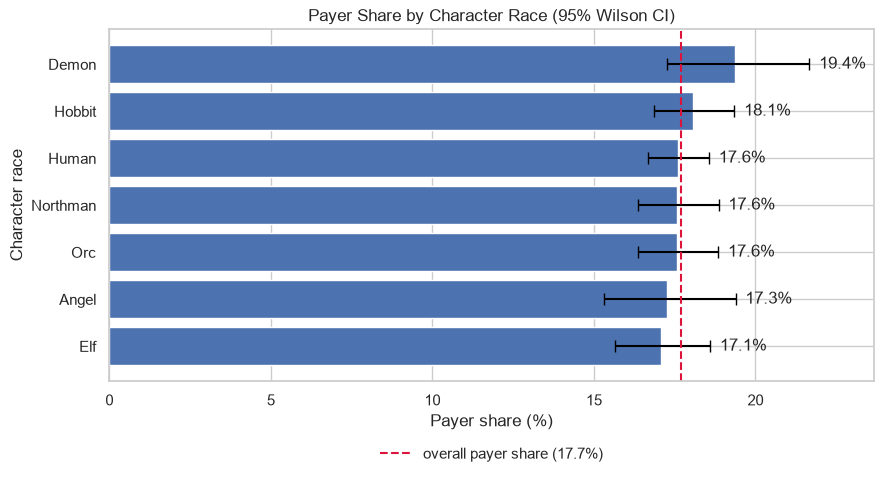

In [7]:
# Wilson score interval — appropriate for proportions with small groups,
# unlike the normal approximation which misbehaves in the tails.
import numpy as np

z = 1.96
p = plot_data["payer_share"].to_numpy()
n = plot_data["players_race"].to_numpy()
centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
lo, hi = centre - half, centre + half

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_data["race"], p * 100)
ax.errorbar(p * 100, range(len(plot_data)), xerr=[(p - lo) * 100, (hi - p) * 100], fmt="none", ecolor="black", capsize=4)

ax.set_xlabel("Payer share (%)")
ax.set_ylabel("Character race")
ax.set_title("Payer Share by Character Race (95% Wilson CI)")
ax.set_xlim(0, hi.max() * 100 + 2)

overall = overall_monetization.loc[0, "payer_share"] * 100
ax.axvline(overall, ls="--", color="crimson", lw=1.5, label=f"overall payer share ({overall:.1f}%)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), frameon=False)

for i, (val, h) in enumerate(zip(p * 100, hi * 100)):
    ax.text(h + 0.3, i, f"{val:.1f}%", va="center")

plt.tight_layout()
plt.savefig("../images/payer_share_by_race.png", dpi=150)
plt.show()

### Key Findings

- Overall real-money conversion is **17.7%** (3,929 of 22,214 registered players).
- Payer share by race spans 17.1% (Elf) to 19.4% (Demon), but a chi-squared test of
  independence gives $\chi^2 = 3.64$, df = 6, **p = 0.72**. The null hypothesis of independence is
  not rejected.
- The largest contrast, Demon against all other races pooled, gives p = 0.12 — a post-hoc
  comparison selected on the maximum, against a Bonferroni threshold of 0.007. Demons are also
  the smallest group at 1,229 players and carry the widest confidence interval.
- **What this does and does not establish.** Section 4 shows this comparison supports an MDE of
  17.7% relative while the observed gap is 10.1%, giving power 0.34. So the null result does not
  show that race is irrelevant; it shows that an effect of the size seen here is not detectable
  at this sample size.
- **Implication:** race is not a usable targeting axis, but that recommendation rests on the
  absence of evidence plus the cost of segmenting, not on evidence of absence. Ranking seven
  point estimates without any test would still have produced a worse recommendation.

## 2. In-Game Purchase Analysis

### Objective

The objective of this analysis is to investigate purchasing behavior inside the
game *Secrets of Darkwood*.

The analysis focuses on:

- examining the distribution of purchase amounts;
- identifying potential anomalies in transaction data;
- analyzing the popularity of in-game items;
- understanding purchasing patterns across all recorded transactions.

These insights help evaluate player spending behavior and identify potential
product issues or opportunities for monetization improvements.

### 2.1 Purchase Amount Statistics

First, we examine the overall distribution of purchase amounts.

For all recorded transactions, we calculate:

- total number of transactions;
- total transaction value;
- minimum and maximum purchase amount;
- mean purchase amount;
- median purchase amount;
- standard deviation.

Comparing the mean and the median helps identify whether the purchase amount
distribution is symmetric or heavily skewed by expensive purchases.

In [8]:
purchase_amounts = pd.read_csv(
    "purchase_amounts.csv"
)

purchase_amounts.head()

,amount
0,21.410
1,64.980
2,50.680
3,46.490
4,18.720


In [9]:
purchase_statistics = pd.read_csv("purchase_statistics.csv")   # all rows, zeros included
display(purchase_statistics)

# Every downstream section works on non-zero transactions. The statistics quoted in
# the README refer to that population, so they are recomputed here rather than left
# for the reader to reconcile against the table above.
amounts = purchase_amounts["amount"]           # extract is already filtered to amount > 0
k = int(len(amounts) * 0.001)

nonzero_stats = pd.Series({
    "transactions": len(amounts),
    "total_spend": amounts.sum(),
    "mean": amounts.mean(),
    "median": amounts.median(),
    "std": amounts.std(),
    "CV": amounts.std() / amounts.mean(),
    "P90": amounts.quantile(0.90),
    "P99": amounts.quantile(0.99),
    "max": amounts.max(),
    "top 0.1% share of turnover": amounts.nlargest(k).sum() / amounts.sum(),
})
display(nonzero_stats.to_frame("non-zero transactions"))

,total_transactions,total_spend,min_purchase_amount,max_purchase_amount,avg_purchase_amount,median_purchase_amount,std_purchase_amount
0,1307678,"687,435,819.184",0.000,"486,615.100",525.692,74.860,"2,517.345"


,non-zero transactions
transactions,"1,306,771.000"
total_spend,"687,435,819.930"
mean,526.057
median,74.860
std,"2,518.181"
CV,4.787
P90,"1,107.990"
P99,"7,486.390"
max,"486,615.100"
top 0.1% share of turnover,0.096


In [10]:
# The log-scale histogram shows periodic spikes: prices are quantised.
amounts = purchase_amounts["amount"]
top_prices = amounts.value_counts().head(8)
print(f"{amounts.nunique():,} distinct amounts; the 20 most frequent cover {amounts.value_counts().head(20).sum() / len(amounts):.1%} of all transactions")
display(top_prices.to_frame("transactions").assign(steps=lambda d: (d.index / 7.486).round(1)))

43,575 distinct amounts; the 20 most frequent cover 32.3% of all transactions


,transactions,steps
amount,,
74.860,61929,10.000
374.320,51567,50.000
149.730,41939,20.000
224.590,32868,30.000
37.430,32434,5.000
748.640,30143,100.000
7.490,17913,1.000
299.460,17654,40.000


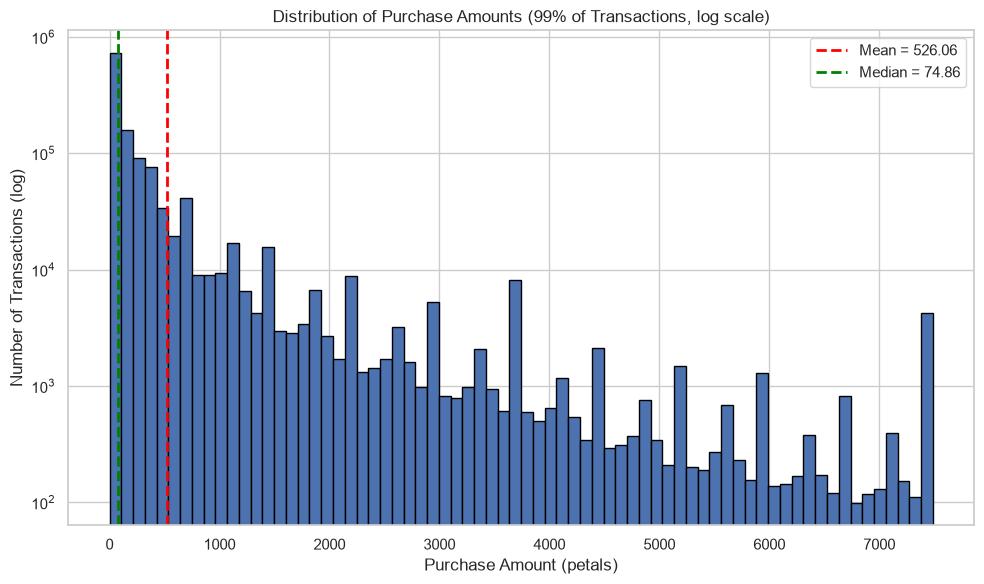

In [11]:
import matplotlib.pyplot as plt
import numpy as np

#99% of purchases
p99 = purchase_amounts["amount"].quantile(0.99)

filtered = purchase_amounts[
    purchase_amounts["amount"] <= p99
]

mean_value = purchase_amounts["amount"].mean()
median_value = purchase_amounts["amount"].median()

plt.figure(figsize=(10, 6))

plt.hist(
    filtered["amount"],
    bins=70,
    edgecolor="black"
)

plt.axvline(
    mean_value,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_value:.2f}"
)

plt.axvline(
    median_value,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_value:.2f}"
)

plt.yscale("log")   # the first bin holds 56% of the plotted mass; on a linear axis the tail this section is about is invisible
plt.title("Distribution of Purchase Amounts (99% of Transactions, log scale)")
plt.xlabel("Purchase Amount (petals)")
plt.ylabel("Number of Transactions (log)")

plt.legend()

plt.tight_layout()
plt.savefig("../images/purchase_distribution.png", dpi=150)
plt.show()

The histogram illustrates the distribution of purchase amounts for the lowest
99% of transactions.

The top 1% of purchases are excluded from the plot for readability. The mean and median lines
are computed on all non-zero transactions, the same population the histogram is drawn from.

**The sawtooth is real, not binning.** Prices sit on a lattice with a step of roughly 7.486
petals: the modal amounts are 74.86 (10 steps), 374.32 (50), 149.73 (20) and 224.59 (30).
Across 43,575 distinct amounts, the twenty most frequent account for 32.3% of all transactions.
The tall bar at the right edge is the 7,486.39 price point (1,000 steps, 4,244 transactions) —
it is a genuine cluster, not a pile-up from the P99 cut, which drops the top 1% rather than
clipping it. Note the consequence for the paragraph above: the median of 74.86 is also the
single most common price in the game, carried by 4.7% of all purchases, so it describes the
pricing grid as much as it describes a typical player.

Several important observations emerge:

- the distribution is strongly right-skewed;
- most purchases have relatively low values;
- a small number of expensive purchases substantially increase the arithmetic
  mean;
- the median provides a more representative estimate of a typical purchase.

### 2.2 Zero-Cost Transactions

Next, we investigate transactions with a purchase amount equal to zero.

Although these transactions do not generate revenue, they may indicate:

- promotional giveaways;
- system-generated rewards;
- data quality issues;
- logging or processing errors.

We calculate both the absolute number of zero-cost transactions and their
share among all recorded transactions.

In [12]:
zero_cost_transactions = pd.read_csv("zero_cost_transactions.csv")
display(zero_cost_transactions.style.format({"zero_cost_share": "{:.6f}"}))

,zero_cost_transactions,zero_cost_share
0,907,0.000694


In [13]:
zero_count = int(zero_cost_transactions.loc[0, "zero_cost_transactions"])
zero_share = zero_cost_transactions.loc[0, "zero_cost_share"] * 100

print(f"Zero-cost transactions: {zero_count:,}")
print(f"Share of all transactions: {zero_share:.4f}%")

Zero-cost transactions: 907
Share of all transactions: 0.0694%


In [14]:
# The four hypotheses in the cell above are testable on the data at hand.
# Which one holds changes whether these rows are a defect or a product feature.
zero_events = pd.read_csv("zero_cost_events.csv")   # extract from sql/02_in_game_purchases.sql

print(f"rows {len(zero_events):,} | unique players {zero_events.id.nunique():,} "
      f"| unique items {zero_events.item_code.nunique()} "
      f"| unique sellers {zero_events.seller_id.nunique():,}")

print(zero_events["game_items"].value_counts().to_string())

# Concentration: are these spread across the base, or generated by a few accounts?
per_player = zero_events["id"].value_counts()
top_id = per_player.index[0]
top = zero_events[zero_events["id"] == top_id]
print(f"\ntop account {top_id}: {len(top)} of {len(zero_events)} rows ({len(top) / len(zero_events):.1%}), null seller_id in {top['seller_id'].isna().sum()} of {len(top)}, active {top['date'].min()} to {top['date'].max()}")

rest = zero_events[zero_events["id"] != top_id]
print(f"remaining {len(rest)} rows from {rest['id'].nunique()} players, spread over {rest['date'].nunique()} dates from {rest['date'].min()} to {rest['date'].max()}")

rows 907 | unique players 72 | unique items 1 | unique sellers 25
game_items
Book of Legends    907

top account 12-1058351: 810 of 907 rows (89.3%), null seller_id in 810 of 810, active 2020-01-31 to 2020-05-24
remaining 97 rows from 71 players, spread over 81 dates from 2020-01-03 to 2021-04-01


**Profiled rather than assumed.** The 907 zero-cost rows are not spread across the base. Every
one of them is the same item (*Book of Legends*), and a single account, `12-1058351`, produces
810 of them — up to 40 per day between 2020-01-31 and 2020-05-24, with a null `seller_id`
throughout, meaning these were not player-to-player trades. This rules out a promotion, which
would touch many players, and a systematic pricing bug, which would distribute across items:
at the 76.9% base rate for *Book of Legends*, roughly 22 of the remaining 97 rows should have
been other items, and none are. The residual 97 rows come from 71 players, 2 to 13 per month across the full 16-month window with no visible clustering, and are consistent with a low-rate logging artifact or
an unpriced quest reward.

Both populations are excluded from every analysis downstream of section 2.1, but for different
reasons — the first as a single anomalous account, the second as logging noise.

### 2.3 Most Popular Epic Items

Finally, we analyze the popularity of epic in-game items.

For each item, we calculate:

- the total number of purchase transactions;
- the share of all purchase transactions;
- the share of unique buyers who purchased the item.

This analysis helps identify which items dominate player purchases and may
represent the most successful monetization products.

In [15]:
popular_items = pd.read_csv("popular_items.csv")

print(f"{len(popular_items)} distinct epic items; the top two account for {popular_items['transaction_share'].head(2).sum():.1%} of paid transactions")
popular_items.head()

145 distinct epic items; the top two account for 97.7% of paid transactions


,epic_item,total_transactions,transaction_share,buyer_share
0,Book of Legends,1004516,0.769,0.884
1,Bag of Holding,271875,0.208,0.868
2,Necklace of Wisdom,13828,0.011,0.118
3,Gems of Insight,3833,0.003,0.067
4,Treasure Map,3084,0.002,0.055


In [16]:
top10_items = popular_items.sort_values("buyer_share", ascending=False).head(10)

top10_items

,epic_item,total_transactions,transaction_share,buyer_share
0,Book of Legends,1004516,0.769,0.884
1,Bag of Holding,271875,0.208,0.868
2,Necklace of Wisdom,13828,0.011,0.118
3,Gems of Insight,3833,0.003,0.067
4,Treasure Map,3084,0.002,0.055
5,Silver Flask,795,0.001,0.046
6,Amulet of Protection,1078,0.001,0.032
7,Glowing Pendant,563,0.000,0.026
8,Strength Elixir,580,0.000,0.024
9,Ring of Wisdom,379,0.000,0.022


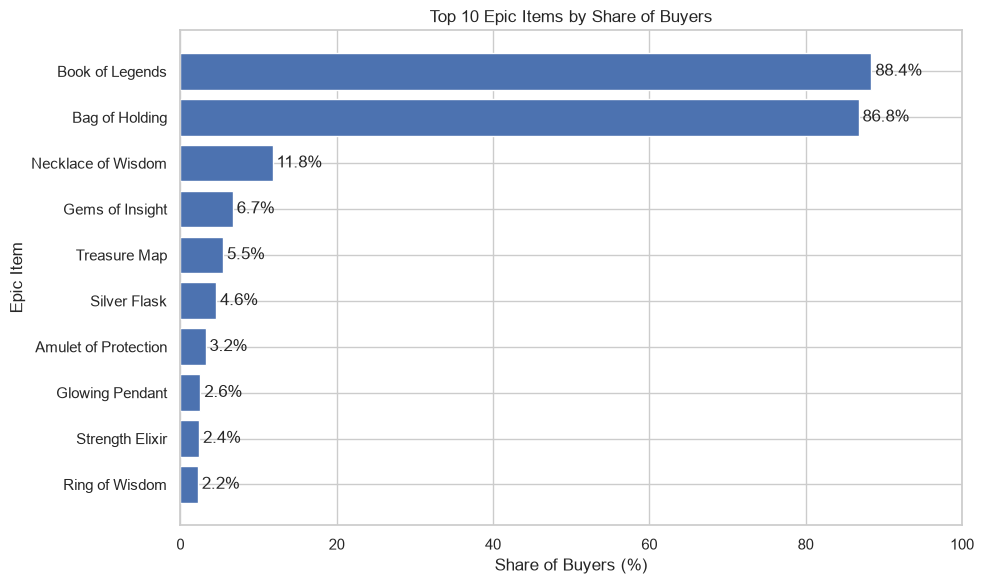

In [17]:
plt.figure(figsize=(10,6))

plt.barh(
    top10_items["epic_item"],
    top10_items["buyer_share"] * 100
)

plt.xlabel("Share of Buyers (%)")
plt.ylabel("Epic Item")
plt.title("Top 10 Epic Items by Share of Buyers")

plt.gca().invert_yaxis()

for i, value in enumerate(top10_items["buyer_share"] * 100):
    plt.text(
        value + 0.5,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.xlim(0, 100)
plt.tight_layout()
plt.savefig("../images/top_epic_items.png", dpi=150)
plt.show()

The popularity of epic items is highly concentrated.

Two items — **Book of Legends** and **Bag of Holding** — dominate player
purchases, with both being bought by more than 85% of all purchasing players.

The remaining items have substantially smaller buyer shares, indicating a
long-tail distribution of player demand across epic items.

This suggests that only a small number of products account for the majority
of player engagement with premium content.

### Key Findings

- Purchase amounts are highly right-skewed, with a small number of expensive
  transactions substantially increasing the average purchase value.
- The median purchase amount provides a more representative estimate of a
  typical transaction than the arithmetic mean.
- Zero-cost transactions account for 0.069% of all purchases and do not move the aggregates,
  but they are not random noise: 89% of them come from a single account acquiring one item
  with no seller recorded, and the rest is a low-rate background across 71 players. Both are
  excluded, for different reasons.
- Player demand for epic items is highly concentrated: two products dominate
  purchases, while the remaining items form a long tail with relatively low
  buyer shares.

## 3. Race Balance (Ad Hoc Request)

**Request.** The analytics team hypothesizes that some races are harder to play and therefore
require more epic item purchases to progress. The design goal is parity — no race should be
markedly easier or harder than another.

Note that this is a **game design** question, not a marketing segmentation question. Purchase
intensity is read here as a proxy for progression difficulty.

**Metrics per race:** registered players, buyers and buyer share, payer share among buyers,
purchases per buyer, average purchase amount, total spend per buyer.

In [18]:
race_activity = pd.read_csv("race_activity.csv")
race_activity

,race,total_registered_players,total_buyers,buyers_registered_share,payers_buyers_share,avg_purchases_per_buyer,avg_purchase_amount,spend_per_buyer
0,Human,6328,3921,0.620,0.180,121.402,403.131,"48,940.963"
1,Angel,1327,820,0.618,0.167,106.805,455.678,"48,668.651"
2,Hobbit,3648,2266,0.621,0.177,86.129,552.903,"47,620.918"
3,Northman,3562,2229,0.626,0.182,82.102,761.501,"62,520.651"
4,Orc,3619,2276,0.629,0.174,81.738,510.900,"41,760.035"
5,Elf,2501,1543,0.617,0.163,78.791,682.335,"53,761.612"
6,Demon,1229,737,0.600,0.199,77.870,529.055,"41,197.382"


In [19]:
from scipy import stats

players = pd.read_csv("player_spend.csv")

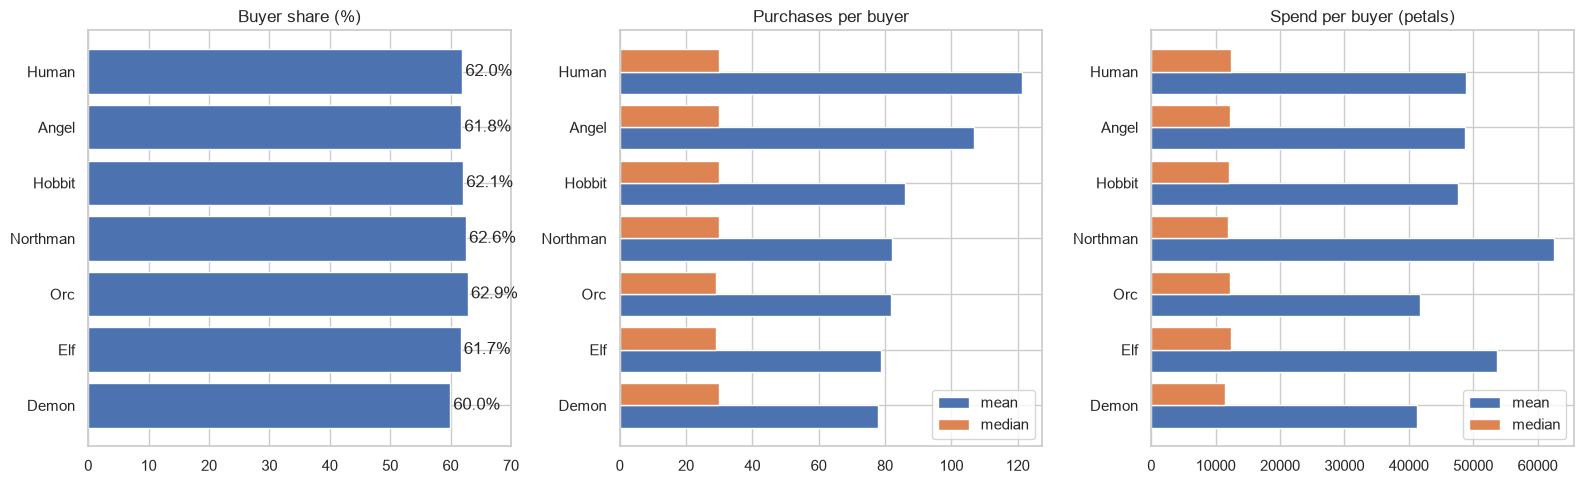

In [20]:
med = players.groupby("race").agg(
    median_purchases=("purchases", "median"),
    median_spend=("total_spend", "median"),
)
d = race_activity.merge(med, left_on="race", right_index=True).sort_values("avg_purchases_per_buyer")
y = np.arange(len(d))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].barh(d["race"], d["buyers_registered_share"] * 100)
axes[0].set_title("Buyer share (%)")
for i, v in enumerate(d["buyers_registered_share"] * 100):
    axes[0].text(v + 0.5, i, f"{v:.1f}%", va="center")
axes[0].set_xlim(0, 70)

axes[1].barh(y - 0.2, d["avg_purchases_per_buyer"], height=0.4, label="mean")
axes[1].barh(y + 0.2, d["median_purchases"], height=0.4, label="median")
axes[1].set_yticks(y)
axes[1].set_yticklabels(d["race"])
axes[1].set_title("Purchases per buyer")
axes[1].legend()

axes[2].barh(y - 0.2, d["spend_per_buyer"], height=0.4, label="mean")
axes[2].barh(y + 0.2, d["median_spend"], height=0.4, label="median")
axes[2].set_yticks(y)
axes[2].set_yticklabels(d["race"])
axes[2].set_title("Spend per buyer (petals)")
axes[2].legend()

plt.tight_layout()
plt.savefig("../images/race_activity.png", dpi=150)
plt.show()

In [21]:
# Means vs medians per race. With a heavy tail these can diverge sharply —
# a single outlier moves the mean but not the median.
summary = players.groupby("race").agg(
    buyers=("purchases", "size"),
    mean_purchases=("purchases", "mean"),
    median_purchases=("purchases", "median"),
    max_purchases=("purchases", "max"),
    mean_spend=("total_spend", "mean"),
    median_spend=("total_spend", "median"),
)
display(summary.round(1))   # rounding for display only — the spread below is computed exact

for col, label in [("mean_purchases", "mean"), ("median_purchases", "median")]:
    lo, hi = summary[col].min(), summary[col].max()
    print(f"purchases per buyer, {label:6}: {lo:>7,.1f} – {hi:>7,.1f}  spread {(hi/lo-1)*100:5.1f}%")

# Kruskal-Wallis: rank-based, so unaffected by the extreme tail that
# destabilises the means. Tests whether the distributions differ at all.
groups = [g["purchases"].to_numpy() for _, g in players.groupby("race")]
print(f"\nKruskal-Wallis, purchases per buyer: p = {stats.kruskal(*groups).pvalue:.4f}")

groups_spend = [g["total_spend"].to_numpy() for _, g in players.groupby("race")]
print(f"Kruskal-Wallis, spend per buyer:    p = {stats.kruskal(*groups_spend).pvalue:.4f}")

,buyers,mean_purchases,median_purchases,max_purchases,mean_spend,median_spend
race,,,,,,
Angel,820,106.800,30.000,10828,"48,668.700","12,206.200"
Demon,737,77.900,30.000,13084,"41,197.400","11,454.200"
Elf,1543,78.800,29.000,24010,"53,761.600","12,352.700"
Hobbit,2266,86.100,30.000,13591,"47,620.900","12,097.300"
Human,3921,121.400,30.000,88304,"48,941.000","12,316.200"
Northman,2229,82.100,30.000,13601,"62,520.700","11,865.900"
Orc,2276,81.700,29.000,22778,"41,760.000","12,203.400"


purchases per buyer, mean  :    77.9 –   121.4  spread  55.9%
purchases per buyer, median:    29.0 –    30.0  spread   3.4%

Kruskal-Wallis, purchases per buyer: p = 0.9494
Kruskal-Wallis, spend per buyer:    p = 0.9049


In [22]:
# The outlier story, quantified rather than asserted.
top = players["purchases"].idxmax()
print(players.loc[top, ["player_id", "race", "purchases", "total_spend"]].to_string())

for label, df in [("with", players), ("without", players.drop(top))]:
    m = df.groupby("race")["purchases"].mean()
    print(f"{label:8} outlier: {m.min():.1f} – {m.max():.1f} (max = {m.idxmax()}), spread {(m.max()/m.min()-1)*100:.1f}%")

player_id        87-1832423
race                  Human
purchases             88304
total_spend   4,160,387.019
with     outlier: 77.9 – 121.4 (max = Human), spread 55.9%
without  outlier: 77.9 – 106.8 (max = Angel), spread 37.2%


In [23]:
# Two accounts dominate the tail on different metrics. Both are flagged as data
# quality candidates before any aggregate built on them is used in production.
for metric in ["purchases", "total_spend"]:
    row = players.loc[players[metric].idxmax()]
    print(f"max {metric}: {row.player_id} ({row.race}), {row.purchases:,} purchases, {row.total_spend:,.0f} petals, avg ticket {row.avg_purchase_amount:,.0f}, {row.total_spend / players.total_spend.sum() * 100:.2f}% of turnover")

# Race-level sensitivity to the single largest spender.
no_whale = players.drop(players["total_spend"].idxmax())
for label, df in [("with", players), ("without", no_whale)]:
    s = df.groupby("race")["total_spend"].mean()
    print(f"spend per buyer, {label:8}: Northman {s['Northman']:>9,.0f} | "
          f"spread {(s.max()/s.min()-1)*100:.1f}%")

max purchases: 87-1832423 (Human), 88,304 purchases, 4,160,387 petals, avg ticket 47, 0.61% of turnover
max total_spend: 08-8623692 (Northman), 596 purchases, 28,474,148 petals, avg ticket 47,775, 4.14% of turnover
spend per buyer, with    : Northman    62,521 | spread 51.8%
spend per buyer, without : Northman    49,769 | spread 30.5%


In [24]:
# Equivalence, not just non-rejection. A large p-value says the data is compatible
# with parity; it does not say by how much parity could be violated undetected.
rng = np.random.default_rng(0)
rows = []
for race, g in players.groupby("race"):
    a = g["purchases"].to_numpy()
    b = players.loc[players["race"] != race, "purchases"].to_numpy()
    boot = np.array([np.median(rng.choice(a, a.size)) / np.median(rng.choice(b, b.size))
                     for _ in range(2000)])
    rows.append((race, g.shape[0], np.median(a) / np.median(b), *np.quantile(boot, [0.025, 0.975])))

equiv = pd.DataFrame(rows, columns=["race", "buyers", "median ratio", "CI low", "CI high"])
display(equiv.round(3))
print(f"widest interval: [{equiv['CI low'].min():.3f}, {equiv['CI high'].max():.3f}]")

# Buyer share by race — asserted as near-uniform in the write-up, so tested rather than eyeballed.
tab = np.c_[race_activity["total_buyers"], race_activity["total_registered_players"] - race_activity["total_buyers"]]
chi2_b, p_b, dof_b, _ = stats.chi2_contingency(tab)
print(f"Buyer share by race: chi2 = {chi2_b:.2f}, df = {dof_b}, p = {p_b:.2f}")

,race,buyers,median ratio,CI low,CI high
0,Angel,820,1.000,0.897,1.103
1,Demon,737,1.000,0.900,1.138
2,Elf,1543,0.967,0.900,1.034
3,Hobbit,2266,1.000,0.933,1.103
4,Human,3921,1.000,0.933,1.069
5,Northman,2229,1.000,0.933,1.069
6,Orc,2276,0.967,0.903,1.069


widest interval: [0.897, 1.138]
Buyer share by race: chi2 = 3.96, df = 6, p = 0.68


In [25]:
# The race table reports total spend / total purchases — a pooled ratio over
# transactions, not an average over players. It spans a wider range than the column
# this section is built around, so it gets the same treatment rather than being
# left unexplained in the main table.
pooled = race_activity.set_index("race")["avg_purchase_amount"]
print(f"pooled avg ticket: {pooled.min():.1f} ({pooled.idxmin()}) – {pooled.max():.1f} ({pooled.idxmax()}), spread {(pooled.max() / pooled.min() - 1) * 100:.1f}%")

ticket = players.groupby("race")["avg_purchase_amount"]
print(f"per-player median ticket: {ticket.median().min():.1f} – {ticket.median().max():.1f}, spread {(ticket.median().max() / ticket.median().min() - 1) * 100:.1f}%")
groups_ticket = [g["avg_purchase_amount"].to_numpy() for _, g in players.groupby("race")]
print(f"Kruskal-Wallis, average ticket per player: p = {stats.kruskal(*groups_ticket).pvalue:.4f}")

# Secondary observation: does spending petals predict paying real money?
# Stated as an equivalence claim, so it needs an interval, not two similar point estimates.
z_w = 1.96
k, n = int(players["payer"].sum()), len(players)
p_hat = k / n
centre = (p_hat + z_w**2 / (2 * n)) / (1 + z_w**2 / n)
half = z_w * np.sqrt(p_hat * (1 - p_hat) / n + z_w**2 / (4 * n**2)) / (1 + z_w**2 / n)
print(f"\npayer share among buyers: {p_hat:.4f}, 95% Wilson CI [{centre - half:.4f}, {centre + half:.4f}] against {3929 / 22214:.4f} across the whole registered base")

pooled avg ticket: 403.1 (Human) – 761.5 (Northman), spread 88.9%
per-player median ticket: 374.7 – 410.1, spread 9.4%
Kruskal-Wallis, average ticket per player: p = 0.3229

payer share among buyers: 0.1772, 95% Wilson CI [0.1709, 0.1837] against 0.1769 across the whole registered base


**What the data shows.** On means, purchases per buyer range from 77.9 (Demon) to 121.4
(Human) — an apparent spread of 55.9%, which would suggest a serious balance problem.

**On medians, that spread disappears:** every race sits at 29–30 purchases, a spread of 3.4%.
A Kruskal-Wallis test — rank-based, and therefore not destabilised by the tail — returns
**p = 0.949** for purchases per buyer and **p = 0.905** for spend per buyer. Neither test
distinguishes the distributions; what that does and does not license is spelled out below.

**What produced the illusion.** The mean is not a stable statistic on this distribution. The
largest single account (Human, 88,304 purchases against a group median of 30) accounts for
about a third of the observed spread: removing it moves the range from 77.9–121.4 (55.9%) to
77.9–106.8 (37.2%), and the maximum shifts to Angel — a race that account does not touch. The
residual 37.2% is the heavy tail acting on every group, not a single anomaly. Group *medians*
sit at 29–30 regardless, which is why the parity conclusion rests on the rank-based test and
not on the means.

**Answer to the request.** Framed as an equivalence question rather than a null-hypothesis one:
a bootstrap CI on the ratio of each race's median purchases to the pooled remainder is
contained in [0.90, 1.14] across all seven races, widest for Demon (n = 737 buyers). Since
median purchases are small integers, the bootstrap resolution is one purchase in thirty, so
these bounds are coarse: the data can rule out a race needing roughly 5 more purchases than
another over a player's lifetime, and cannot rule out 2. Buyer share is likewise near-uniform
at 60.0–62.9% (chi-squared test of independence, p = 0.68). No race requires materially more
epic item purchases to progress at any tolerance the design team is likely to care about, but
the data does not support a stronger claim. The Kruskal-Wallis p = 0.949 on its own would not
have licensed this statement: a large p-value is not evidence of equivalence.

**The pooled average ticket is a different statistic and should not be read as a per-player
one.** The race table reports total spend divided by total purchases, spanning 403 (Human) to
762 (Northman) — an 88.9% spread, wider than the purchases-per-buyer figure above. It is a
ratio of sums over transactions, dominated by the same two tail accounts. At the player grain
the median ticket spans 375–410 (9.4%) and Kruskal-Wallis returns p = 0.32. The parity
conclusion is unaffected, but the column is easy to misread.

**Secondary observation.** Payer share among buyers is 17.72%, with a 95% Wilson CI of
[17.09%, 18.37%] at n = 13,792 — an interval that comfortably contains the 17.69% payer share
across the whole registered base. Spending petals in-game and paying real money for them are
independent to within roughly ±0.7 pp. Unlike the race-parity claim above, this equivalence is
tight enough to be useful: buyer status is not a proxy for payer status, and targeting one on
the basis of the other has no support here.

**Limitations.**
- Race is chosen by the player, not assigned at random, so even a genuine difference could
  reflect self-selection rather than game design. None was found, so this does not bite here.
- Two accounts should be reviewed as possible data quality issues before any of these
  aggregates are used in production. Player 87-1832423 (Human) has 88,304 purchases against a
  group median of 30 and dominates the *purchase count* mean. Player 08-8623692 (Northman) has
  an average ticket of 47,775 petals sustained over 596 purchases — against a global median
  ticket of 74.86 and a maximum single transaction of 486,615 — and alone accounts for 4.14% of
  all in-game turnover. Without the second account Northman is no longer the top race by spend per buyer (62,521 -> 49,769, and the lead passes to Elf); the cross-race spread on that metric falls from 51.8% to 30.5%. It is also the single largest contributor to the variance that section 4 is built around.
- The smallest race group has 1,229 registered players. Against all other races pooled this
  supports an MDE of 17.7% relative on conversion; the gap actually observed is 10.1%, at which
  the comparison has power 0.34 (see section 4). Non-detection here is an absence of evidence,
  not evidence of absence.

## 4. Metric Validation and Experiment Design

Sections 1–3 describe what the product currently does. This section asks which effects are
**detectable at all** on this audience, and therefore which of the marketing team's proposed
changes are worth testing.

No experiment was run in the game. Historical data is used as a testbed:

1. **A/A simulation** — players split at random with no treatment. Since no true effect exists
   by construction, a correctly calibrated test must reject in ~5% of runs and produce
   uniformly distributed p-values.
2. **MDE** — the minimum detectable effect at the current audience size.
3. **Power simulation** — a synthetic effect is injected into one group.

Two candidate metrics are evaluated: **real-money conversion** (binary, the revenue-bearing
metric) and **in-game spend per registered player** (continuous, heavy-tailed, with non-buyers
entering as zeros).

In [26]:
import numpy as np
from scipy import stats

ALPHA, POWER, N_SIM, SEED = 0.05, 0.80, 1000, 42
z_a, z_b = stats.norm.ppf(1 - ALPHA / 2), stats.norm.ppf(POWER)

players = pd.read_csv("player_spend.csv")
spend = players["total_spend"].to_numpy(float)

print(f"Buyers: {len(spend):,}")
print(f"Mean {spend.mean():,.1f} | Median {np.median(spend):,.1f} | "
      f"P90 {np.quantile(spend, 0.9):,.1f} | Max {spend.max():,.1f}")
print(f"CV: {spend.std(ddof=1) / spend.mean():.2f}")

# ITT grain. `player_spend` is buyers only (13,792 of 22,214) because the SQL
# extract inner-joins on events. Being a buyer is a post-randomisation outcome,
# so a per-buyer mean is conditioned on treatment and is not an ITT estimand.
# The experiment metric is therefore spend per *registered player*, with
# non-buyers entering as zeros.
N_REGISTERED = 22_214
spend_itt = np.concatenate([spend, np.zeros(N_REGISTERED - len(spend))])

print(f"Buyers {len(spend):,} | Registered {N_REGISTERED:,} | "
      f"Non-buyers {N_REGISTERED - len(spend):,}")
print(f"ARPU (ITT grain): mean {spend_itt.mean():,.1f} | CV {spend_itt.std(ddof=1)/spend_itt.mean():.2f}")

Buyers: 13,792
Mean 49,843.1 | Median 12,167.8 | P90 90,977.5 | Max 28,474,147.8
CV: 6.03
Buyers 13,792 | Registered 22,214 | Non-buyers 8,422
ARPU (ITT grain): mean 30,946.1 | CV 7.70


In [27]:
def aa_pvalues(values, n_sim=N_SIM, seed=SEED):
    """Random A/A split, n_sim times. No treatment is applied, so the share of
    runs with p < alpha estimates the test's actual type I error rate here."""
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    n = len(values)
    out = np.empty(n_sim)
    for i in range(n_sim):
        mask = rng.permutation(n) < n // 2
        out[i] = stats.ttest_ind(values[mask], values[~mask], equal_var=False).pvalue
    return out

pv = aa_pvalues(spend_itt)
print(f"Observed FPR: {(pv < ALPHA).mean():.3f} (nominal {ALPHA})")
print(f"KS test for uniformity: p = {stats.kstest(pv, 'uniform').pvalue:.3f}")

Observed FPR: 0.027 (nominal 0.05)
KS test for uniformity: p = 0.000


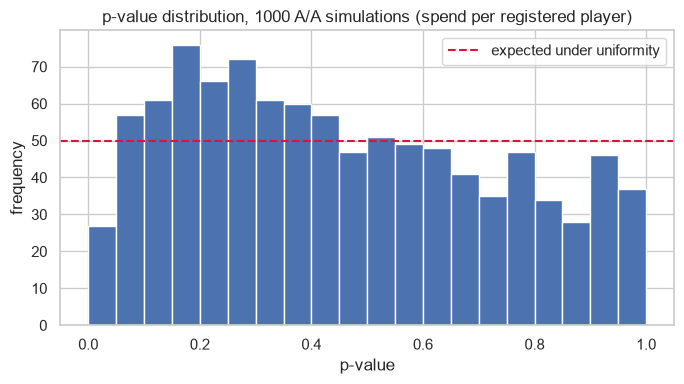

In [28]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(pv, bins=20, range=(0, 1), edgecolor="white")
ax.axhline(N_SIM / 20, ls="--", color="crimson", lw=1.5, label="expected under uniformity")
ax.set_xlabel("p-value")
ax.set_ylabel("frequency")
ax.set_title(f"p-value distribution, {N_SIM} A/A simulations (spend per registered player)")
ax.legend()

plt.tight_layout()
plt.savefig("../images/aa_pvalue_distribution.png", dpi=150)
plt.show()

In [29]:
# Calibration and sensitivity for every candidate specification, generated rather
# than transcribed so the table cannot drift from the code that produced it.
def aa_pvalues_test(values, test, n_sim=N_SIM, seed=SEED):
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    n = len(values)
    out = np.empty(n_sim)
    for i in range(n_sim):
        mask = rng.permutation(n) < n // 2
        out[i] = test(values[mask], values[~mask]).pvalue
    return out

welch = lambda a, b: stats.ttest_ind(a, b, equal_var=False)
mwu = lambda a, b: stats.mannwhitneyu(a, b)

specs = [
    ("raw", spend_itt, welch),
    ("winsorized P99", np.clip(spend_itt, None, np.quantile(spend_itt, 0.99)), welch),
    ("winsorized P95", np.clip(spend_itt, None, np.quantile(spend_itt, 0.95)), welch),
    ("Mann-Whitney", spend_itt, mwu),
]

rows = []
for name, v, test in specs:
    p = aa_pvalues_test(v, test)
    parametric = test is welch
    rows.append({
        "specification": name,
        "FPR": (p < ALPHA).mean(),
        "KS p": stats.kstest(p, "uniform").pvalue,
        "CV": v.std(ddof=1) / v.mean() if parametric else np.nan,
        "MDE": ((z_a + z_b) * np.sqrt(2 * v.var(ddof=1) / (len(v) // 2)) / v.mean()
                 if parametric else np.nan),
    })

calibration = pd.DataFrame(rows)
display(calibration.style.format({"FPR": "{:.3f}", "KS p": "{:.3f}", "CV": "{:.2f}", "MDE": "{:.1%}"}, na_rep="—"))

# Distribution shape, quoted in the write-up below.
print(f"skewness {stats.skew(spend_itt):.1f} | "
      f"excess kurtosis {stats.kurtosis(spend_itt):,.0f} | "
      f"max/mean {spend_itt.max() / spend_itt.mean():.0f}")

,specification,FPR,KS p,CV,MDE
0,raw,0.027,0.000,7.70,28.9%
1,winsorized P99,0.063,0.143,2.67,10.0%
2,winsorized P95,0.061,0.097,1.77,6.7%
3,Mann-Whitney,0.050,0.817,—,—


skewness 81.0 | excess kurtosis 9,239 | max/mean 920


In [30]:
# MDE for both candidate metrics, at the audience size actually available.

# Continuous metric: spend per registered player (ITT grain)
n_grp = len(spend_itt) // 2
mde_spend = (z_a + z_b) * np.sqrt(2 * spend_itt.var(ddof=1) / n_grp)

# Binary metric: real-money conversion across the full registered base
p0, n_conv = 3929 / 22214, 22214 // 2
mde_conv = (z_a + z_b) * np.sqrt(2 * p0 * (1 - p0) / n_conv)

print(f"Spend per player n/group {n_grp:>6,}: MDE {mde_spend/spend_itt.mean()*100:5.1f}% relative")
print(f"Conversion n/group {n_conv:>6,}: MDE {mde_conv*100:5.2f} pp = {mde_conv/p0*100:.1f}% relative")

# Smallest race group. The comparison actually made in section 1 is Demon vs all
# other races pooled — unequal groups — not a split inside the Demon population.
def mde_prop(p, n1, n2):
    return (z_a + z_b) * np.sqrt(p * (1 - p) * (1 / n1 + 1 / n2))

n_demon, n_rest = 1229, 22214 - 1229
print(f"Demon vs rest ({n_demon:,} / {n_rest:,}): MDE {mde_prop(p0, n_demon, n_rest) / p0 * 100:.1f}% relative")

# Realised power at the gap actually observed — the number that decides whether
# "no difference" is a finding or an absence of one.
p_d, p_r = 238 / n_demon, (3929 - 238) / n_rest
se = np.sqrt(p_d * (1 - p_d) / n_demon + p_r * (1 - p_r) / n_rest)
delta = abs(p_d - p_r)
power_obs = stats.norm.sf(z_a - delta / se) + stats.norm.cdf(-z_a - delta / se)
print(f"Observed gap {p_d:.3f} vs {p_r:.3f} ({delta / p_r * 100:.1f}% rel): power = {power_obs:.2f}")

Spend per player n/group 11,107: MDE  28.9% relative
Conversion n/group 11,107: MDE  1.43 pp = 8.1% relative
Demon vs rest (1,229 / 20,985): MDE 17.7% relative
Observed gap 0.194 vs 0.176 (10.1% rel): power = 0.34


In [31]:
def power_sim(values, effect, n_sim=500, seed=SEED + 1, winsorize_q=None):
    """Injects the effect on the RAW scale, then applies variance reduction — the
    order a real experiment forces. The cap is re-estimated on the pooled
    post-treatment sample each run, because that is the only cap available in
    practice. Winsorizing first would let the threshold move with the treatment
    and deliver the full lift to the test, overstating power."""
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    n, rejected = len(values), 0
    for _ in range(n_sim):
        mask = rng.permutation(n) < n // 2
        a, b = values[mask], values[~mask] * (1 + effect)
        if winsorize_q is not None:
            cap = np.quantile(np.concatenate([a, b]), winsorize_q)
            a, b = np.clip(a, None, cap), np.clip(b, None, cap)
        rejected += stats.ttest_ind(a, b, equal_var=False).pvalue < ALPHA
    return rejected / n_sim

# Grid refined around both 80% crossings so they are resolved by simulation
# rather than by linear interpolation between distant points.
effects = [0.05, 0.10, 0.125, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]

power_df = pd.DataFrame({
    "effect": [f"{e * 100:.4g}%" for e in effects],
    "power (raw)": [power_sim(spend_itt, e) for e in effects],
    "power (winsorized P99)": [power_sim(spend_itt, e, winsorize_q=0.99) for e in effects],
})
power_df

,effect,power (raw),power (winsorized P99)
0,5%,0.062,0.200
1,10%,0.150,0.576
2,12.5%,0.206,0.766
3,15%,0.278,0.894
4,20%,0.428,0.972
5,25%,0.550,0.998
6,30%,0.720,1.000
7,35%,0.838,1.000
8,40%,0.934,1.000


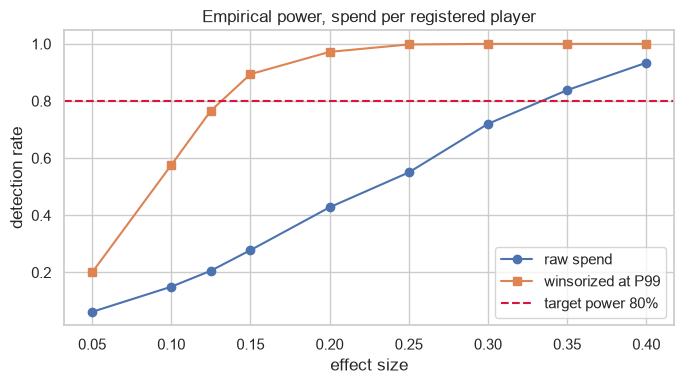

In [32]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(effects, power_df["power (raw)"], "o-", label="raw spend")
ax.plot(effects, power_df["power (winsorized P99)"], "s-", label="winsorized at P99")
ax.axhline(0.8, ls="--", color="crimson", lw=1.5, label="target power 80%")
ax.set_xlabel("effect size")
ax.set_ylabel("detection rate")
ax.set_title("Empirical power, spend per registered player")
ax.legend()
plt.tight_layout()
plt.savefig("../images/power_curve.png", dpi=150)
plt.show()

### Key Findings

- **Welch's t-test is NOT correctly calibrated on raw spend.** Across 1,000 A/A simulations the
  observed false positive rate was **2.7%** against a nominal 5% — a binomial 95% CI of
  [0.019, 0.039], which excludes 0.05 — and the p-value distribution failed a uniformity test
  (**KS p < 0.001**). The test is *conservative* here, not permissive.
- **Cause.** Spend per registered player has skewness 81 and excess kurtosis 9,239; the largest
  value exceeds the mean by a factor of 920. Whichever group receives an extreme account
  acquires an inflated sample variance, the standard error grows, and the test stops rejecting.
  This is a failure of the normal approximation, not of the sample size.
- **Variance reduction repairs calibration and cuts the MDE by roughly two thirds** (table
  above). Winsorizing at P99 brings the false positive rate back inside the nominal level —
  0.063 with a binomial 95% CI of [0.050, 0.080], against [0.019, 0.039] for the raw metric,
  which excludes 5% outright — and the analytic MDE from 28.9% to 10.0%. The repair is real but
  not lavish: the winsorized FPR sits at the upper edge of that interval and the uniformity
  test is no longer comfortable (KS p = 0.14), so P99 is close to the weakest cap that works.
  A rank-based test is calibrated on the raw metric but tests a different null.
- **Metric grain.** All of section 4 runs on spend per *registered* player, with the 8,422
  non-buyers entering as zeros. Spend per *buyer* conditions on a post-randomisation outcome:
  if the treatment moves the purchase decision itself, that comparison is selection-biased and
  is not an ITT estimand. The buyer-grain figures in section 3 are descriptive and unaffected.
- **Real-money conversion remains the better experiment metric.** As a binary metric on the
  full registered base (11,107 per group at p = 0.177) its MDE is **1.43 pp = 8.1% relative**,
  with no distributional assumptions to violate. It is also the only revenue-bearing metric in
  the schema.
- **The analytic MDE understates what the design costs.** Winsorizing gives an analytic MDE of
  10.0%, but that figure assumes the cap is fixed independently of treatment. Re-estimating the
  cap on the pooled post-treatment sample — the only thing available in a live test — clips
  part of the lift: simulated power reaches 0.77 at a 12.5% effect and 0.89 at 15%, so the
  effective 80% threshold is near **13%**, not 10.0%. The analytic number is a lower bound on
  the design's sensitivity, not the design's sensitivity. For comparison, the raw metric needs
  roughly a **33%** lift for the same power (0.72 at 30%, 0.84 at 35%) — variance reduction is
  worth a factor of about 2.5 in detectable effect size, which is what makes it worth doing.
- **Per-race conversion differences below ~18% relative are not detectable.** Demon against all
  other races pooled (1,229 vs 20,985) supports an MDE of 17.7% relative. The gap actually
  observed is 10.1% relative, at which this comparison has power 0.34. The chi-squared null
  result in section 1 therefore does **not** establish that race is irrelevant — it establishes
  that a race effect of the size seen here is not detectable at this sample size. The practical
  recommendation (do not segment by race) follows from the absence of evidence plus the cost of
  segmenting, not from evidence of absence.
- **Reading the power table.** Entries of 1.000 are 500 rejections out of 500 simulations, not
  a claim of certainty: the exact binomial lower bound on the true power there is 0.993. The
  saturation is expected rather than suspicious — at a 25% effect the winsorized metric carries
  a signal of roughly 7 standard errors, at which the analytic miss probability is $2.6\times10^{-7}$.
  Simulation cannot resolve rates that small at 500 draws, and does not need to.

**Recommendation.** Run advertising experiments on the full registered base with real-money
conversion as the primary metric. If in-game spend must be a decision metric, winsorize at P99
and budget for a ~13% threshold, or use a rank-based test where a shift in the distribution
rather than in the mean is an acceptable answer. Never the raw mean: it under-rejects and would
silently kill true effects. A log transform is not recommended on this grain — with 8,422
non-buyers at zero it mixes a point mass with a continuous part, and its apparent sensitivity
is an artifact of the scale rather than a real gain.